# **Design of Experiments: A Hands-on Session**

## What is Design of Experiments (DOE)?

A systematic approach used to study the effects of different inputs / **factors** (e.g., speed, temperature, or vendor) on a process and the outputs / **responses** of that process (e.g, yield, impurity, or cost).

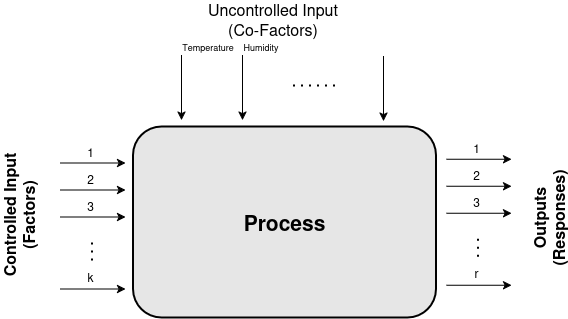

## When should I use DOE?


*   Determine whether a factor, or group of factors, influences a response of interest.
*   Understand the potential relationships among factors and responses.
*   Optimize one or more responses by identifying which factor settings (e.g., a specific temperature and vendor) produce a desired outcome (e.g., greatest yield)



## A Ceramic Manufacturing Process

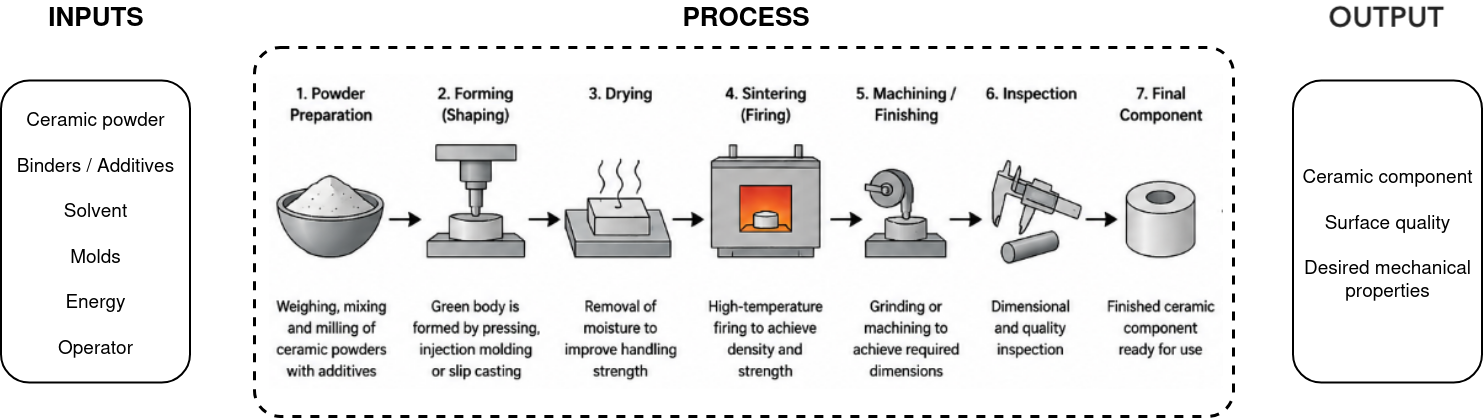

## The Problem: How Can We Improve the Process?

* How to increase the **strength** of the ceramic material?
* Does strength varies depending on the grinding process?
* Which process settings are important?

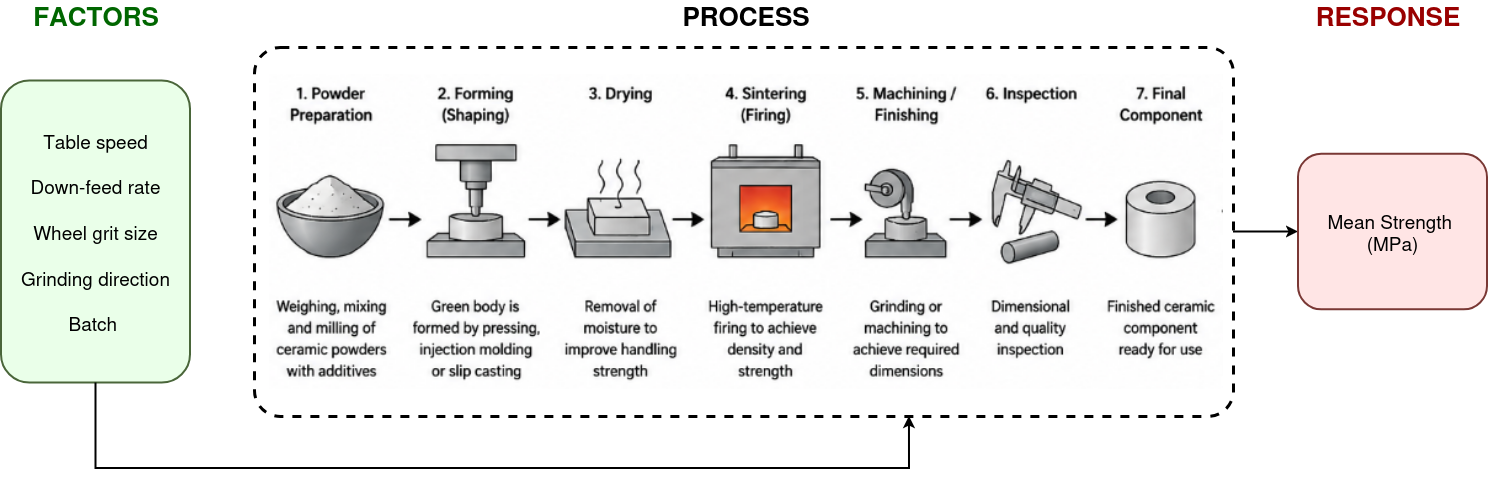

### Experiment

Rather than simply observing the manufacturing process, we deliberately **control selected process factors and measure their effect on ceramic strength**.

### How should we vary these factors so that we can learn which ones matter?

### **Why not change one factor at a time?**
Let’s look at a simple example to illustrate the power of using DOE.

In the one-factor-at-a-time (OFAT) approach, you
* Test a **single factor** by changing the setting, or level, of that factor while keeping **all other factors at a constant level**.
* Repeat this process for each factor in your experiment.

## OFAT Example

Maximize **Yield** of a chemical process. Key factors: **Temperature** and **pH**. At the current settings of your factors (Temperature = 25°C and pH = 5.5), Yield is 83%.

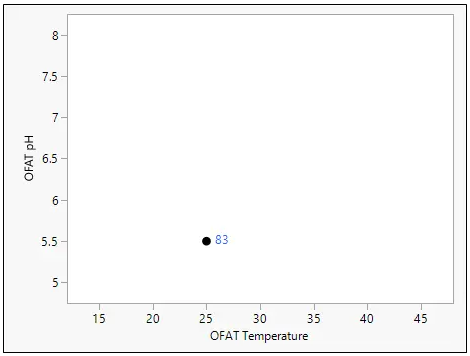

To determine if you can increase the Yield, keep **pH constant** and **vary Temperature**.
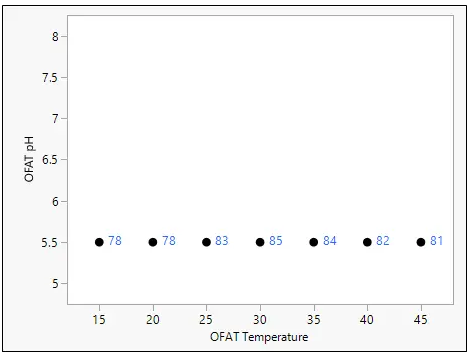

Maximum Yield of 85% occurs when Temperature is set at 30°C

Keep **Temperature constant** and **vary pH**.

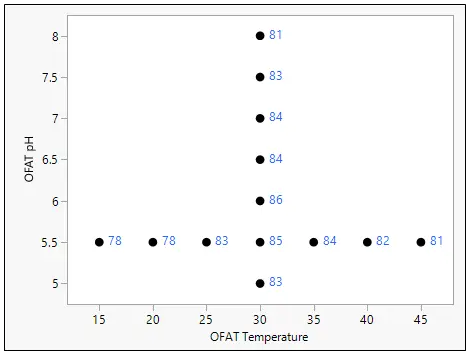

From the outcome of these 13 tests where you varied one factor at a time, you conclude that **Yield is maximized at 86%** when **Temperature is set to 30°C** and **pH is 6**.

* But can we really be sure that this OFAT experiment has captured the **true relationships** between Temperature, pH, and Yield?
* Is there a possibility of an ***interaction*** between these factors?
* You can’t determine if the effect of Temperature on Yield changes depending on the level of pH and vice versa.

## DOE - Key Idea
**We don't just decide what to change - we deliberately design which combinations of factor levels to test.**

## Key Principles of DOE

### **1) Randomization**

Factor: Fertilizer amount

Treatments: A = Low, B = Medium, C = High

Response: Plant height

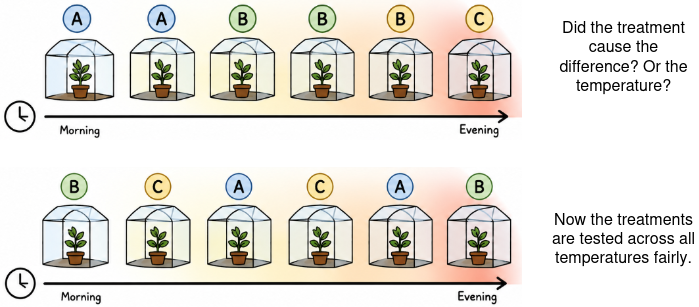

### **2) Replication**

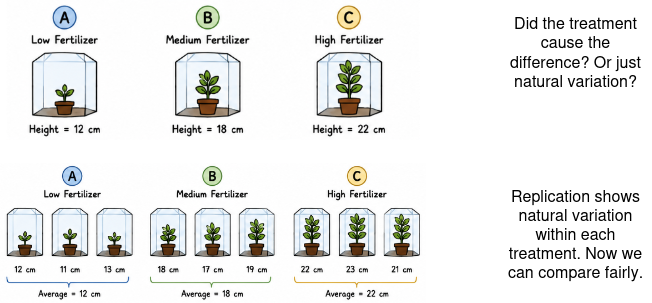

### **3) Blocking**
Temperature in greenhouse varies from one side to the other.

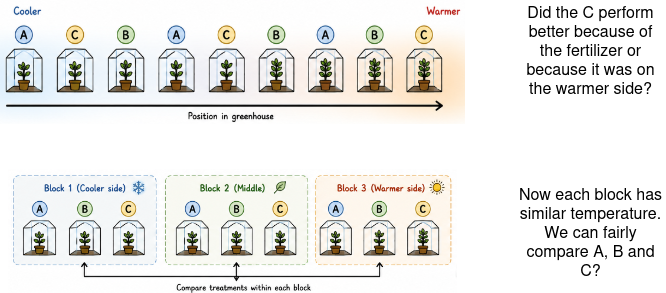

### **Randomization + Replication + Blocking → good experimental data**

### How do we determine whether the factors actually affected the response? **Hypothesis/significance-testing**

### Let's recall Hypothesis testing (Ceramic manufacturing example)

Does the factor **Table speed** has a significant effect on the response **Strength**?
* Collect specimens of the ceramic material manufactured using **Table speed = 10** and note their **Strength**.

* Repeat the same for **Table speed = 20** and note their **Strength**.
* The factor **Table speed** has **2 levels**: 10 and 20. We have 2 groups.


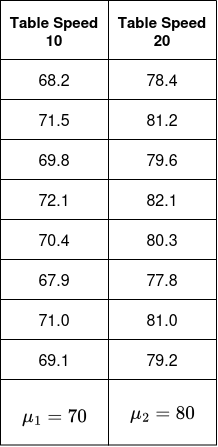

Null Hypothesis $H_0: \mu_1 = \mu_2$ (no effect, the observation is due to random change / environmental noise)

Althernate Hypothesis $H_a: \mu_1 \ne \mu_2$ (there is an effect)

* Z-test → commonly used when population variance is known / large-sample settings.
* t-test → commonly used when population variance is unknown and estimated from the sample.

Both are typically used to compare **one or two means**, depending on the test.

* ### What if the factor has **more than 2 levels**?
* ### What if there are **multiple factors**?
## **An**alysis **O**f **Va**riance (ANOVA)

## One-Way ANOVA
* Used when you have a **single factor**, and your goal is to investigate if variations, or different levels of that factor have a measurable effect on the **response**.
### Limitation:
* It can tell us if at least one pair of means is significantly different, but it **can’t tell us which pair**.
### Hypothesis:
$H_0 : \mu_1 = \mu_2 = \dots = \mu_k$

$H_a :$ not all means are equal

where $\mu_i$ is the mean of the i-th level of the factor (i-th group).


## Python hands-on example: Manufacturing of an adhesive gel
* Imagine you work for a company that manufactures an adhesive gel that is sold in small jars.
* The viscosity of the gel is important: too thick and it becomes difficult to apply; too thin and its adhesiveness suffers.
* Complaint: viscosity of your adhesive is not as consistent as it used to be.

**Experiment:** Examine the average viscosity of the five most recent production lots.

* You measure viscosity using an instrument that rotates a spindle immersed in the jar of adhesive. This test yields a measurement called **torque resistance** (response).

* You test five jars selected randomly from each of the most recent five **lots** (factor). You obtain the torque resistance measurement for each jar and plot the data.

### **Data Exploration**

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy
from scipy.stats import f

from statsmodels.formula.api import ols
import statsmodels.api as sm

In [12]:
df = pd.read_csv('anova.csv')
df

,lot,jar,torque_resistance
0,lot1,jar1,29.39
1,lot1,jar2,31.51
2,lot1,jar3,30.88
3,lot1,jar4,27.63
4,lot1,jar5,28.85
5,lot2,jar1,30.63
6,lot2,jar2,32.10
7,lot2,jar3,30.11
8,lot2,jar4,29.63
9,lot2,jar5,29.68


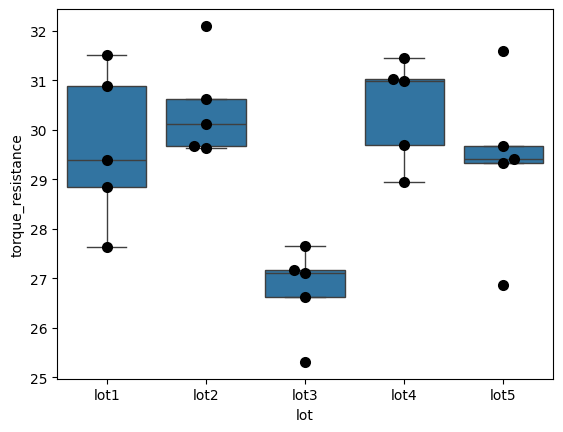

In [13]:
plt.figure(dpi=100)
sns.boxplot(x='lot',y='torque_resistance', data=df)
sns.swarmplot(data=df, x="lot", y="torque_resistance", color="k", size=8)
plt.show()

In [14]:
groups_df = df.pivot(index='lot', columns='jar', values='torque_resistance')
groups_df

jar,jar1,jar2,jar3,jar4,jar5
lot,,,,,
lot1,29.39,31.51,30.88,27.63,28.85
lot2,30.63,32.10,30.11,29.63,29.68
lot3,27.16,26.63,25.31,27.66,27.10
lot4,31.03,30.98,28.95,31.45,29.70
lot5,29.67,29.32,26.87,31.59,29.41


### **Sum of Squares**

The overall variability can be split into two parts:
* the variability due to the factor levels, and
* the variability due to random error.

$\sum_{i=1}^{a}\sum_{j=1}^{n_i}(Y_{ij}-\overline{\overline{Y}})^2\;=\;\sum_{i=1}^{a}n_i(\overline{Y}_i-\overline{\overline{Y}})^2+\sum_{i=1}^{a}\sum_{j=1}^{n_i}(Y_{ij}-\overline{Y}_i)^2$

$SS(Total)\;     =     \;SS(Factor)\;     +     \;SS(Error)$

In [5]:
group_means = groups_df.mean(axis=1)
GROUP_MEANS = [group_means['lot1']] * 5 + [group_means['lot2']] * 5 + [group_means['lot3']] * 5 + [group_means['lot4']] * 5 + [group_means['lot5']] * 5
GRAND_MEAN = [df['torque_resistance'].mean()] * 25

df['group_means'] = GROUP_MEANS
df['grand_mean'] = GRAND_MEAN
df

,lot,jar,torque_resistance,group_means,grand_mean
0,lot1,jar1,29.39,29.652,29.3296
1,lot1,jar2,31.51,29.652,29.3296
2,lot1,jar3,30.88,29.652,29.3296
3,lot1,jar4,27.63,29.652,29.3296
4,lot1,jar5,28.85,29.652,29.3296
5,lot2,jar1,30.63,30.430,29.3296
6,lot2,jar2,32.10,30.430,29.3296
7,lot2,jar3,30.11,30.430,29.3296
8,lot2,jar4,29.63,30.430,29.3296
9,lot2,jar5,29.68,30.430,29.3296


In [6]:
df['sq_diff_between'] = (df['group_means'] - df['grand_mean']) ** 2
df['sq_diff_within'] = (df['torque_resistance'] - df['group_means']) ** 2
df['sq_diff_total'] = (df['torque_resistance'] - df['grand_mean']) ** 2
df

,lot,jar,torque_resistance,group_means,grand_mean,sq_diff_between,sq_diff_within,sq_diff_total
0,lot1,jar1,29.39,29.652,29.3296,0.103942,0.068644,0.003648
1,lot1,jar2,31.51,29.652,29.3296,0.103942,3.452164,4.754144
2,lot1,jar3,30.88,29.652,29.3296,0.103942,1.507984,2.403740
3,lot1,jar4,27.63,29.652,29.3296,0.103942,4.088484,2.888640
4,lot1,jar5,28.85,29.652,29.3296,0.103942,0.643204,0.230016
5,lot2,jar1,30.63,30.430,29.3296,1.210880,0.040000,1.691040
6,lot2,jar2,32.10,30.430,29.3296,1.210880,2.788900,7.675116
7,lot2,jar3,30.11,30.430,29.3296,1.210880,0.102400,0.609024
8,lot2,jar4,29.63,30.430,29.3296,1.210880,0.640000,0.090240
9,lot2,jar5,29.68,30.430,29.3296,1.210880,0.562500,0.122780


In [7]:
# Degrees of freedom
df_between = 4 # k - 1
df_within = 20 # N - k
# Mean square errors
mse_between = df['sq_diff_between'].sum() / df_between
mse_within = df['sq_diff_within'].sum() / df_within

### **The F-Statistic**
$\text{F} = \frac{\text{Variance between groups}}{\text{Variance within groups}}$

In [8]:
F = mse_between / mse_within
print(f'Observed F-statistic = {F}')

Observed F-statistic = 6.899485683411743


### **The F distribution**

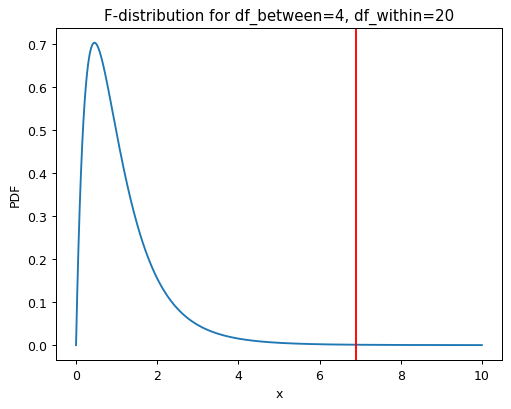

In [9]:
x = np.linspace(0, 10, 1000)
density = f.pdf(x, df_between, df_within)
plt.figure(dpi=90)
plt.plot(x, density)
plt.title('F-distribution for df_between=4, df_within=20')
plt.xlabel('x')
plt.ylabel('PDF')
plt.axvline(F, color='red')
plt.show()

### **p-value** (Significance level, $\alpha=0.05$)

In [10]:
dx = x[1] - x[0]
p_value = density[689:].sum() * dx
print(f'p-value = {p_value}')

p-value = 0.0010438747801372488


### At least one group mean ($\mu_i$) is significantly different: **Null hypothesis can be rejected**.

## Python's built-in function for One-way ANOVA

In [15]:
group1 = np.array(groups_df.loc['lot1', :])
group2 = np.array(groups_df.loc['lot2', :])
group3 = np.array(groups_df.loc['lot3', :])
group4 = np.array(groups_df.loc['lot4', :])
group5 = np.array(groups_df.loc['lot5', :])

In [16]:
F, p_value = scipy.stats.f_oneway(group1, group2, group3, group4, group5)
print(f'Observed F-statistic = {F}')
print(f'p-value = {p_value}')

Observed F-statistic = 6.89948568341173
p-value = 0.0011662941406471524


In [17]:
model = ols('torque_resistance ~ C(lot)', data=df).fit()
anova = sm.stats.anova_lm(model, typ=1)
anova

,df,sum_sq,mean_sq,F,PR(>F)
C(lot),4.0,45.256376,11.314094,6.899486,0.001166
Residual,20.0,32.796920,1.639846,NaN,NaN


## Which groups are significantly different?
An ANOVA test tells you that at least one group mean is different, but it doesn't tell you which ones.

## Why not t-tests for every possible pair?
The pitfall:
* With 5 groups, there are 10 pairwise comparisons.
* If each test has a 5% significance level ($\alpha$=0.05), the overall probability of making at least one false positive (Type I error) across all 10 tests will be $1 - (1 - 0.05)^{10} ≈ 40.1\%$.

## The solution: Tukey's test
Intuition: *"If all groups came from the exact same population (i.e., the null hypothesis is true), what is the **largest possible difference** between the **highest sample mean** and the **lowest sample mean** that could reasonably happen by **random chance**?"*

By modeling the distribution of this extreme gap - known as the **Studentized Range Distribution (q)** - Tukey sets a single threshold for the entire experiment:
* If any two group means differ by more than this threshold, you can safely declare them significantly different.

In [18]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd
tukey = pairwise_tukeyhsd(endog=df['torque_resistance'], groups=df['lot'], alpha=0.05)
print(tukey)

Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
  lot1   lot2    0.778 0.8693 -1.6455  3.2015  False
  lot1   lot3    -2.88 0.0151 -5.3035 -0.4565   True
  lot1   lot4     0.77 0.8735 -1.6535  3.1935  False
  lot1   lot5    -0.28 0.9967 -2.7035  2.1435  False
  lot2   lot3   -3.658 0.0018 -6.0815 -1.2345   True
  lot2   lot4   -0.008    1.0 -2.4315  2.4155  False
  lot2   lot5   -1.058 0.6905 -3.4815  1.3655  False
  lot3   lot4     3.65 0.0018  1.2265  6.0735   True
  lot3   lot5      2.6 0.0318  0.1765  5.0235   True
  lot4   lot5    -1.05 0.6963 -3.4735  1.3735  False
----------------------------------------------------


### **Group 3** is significantly different from all other groups!

## What is we have more than 1 factor? Multi-factor ANOVA

In [21]:
df = pd.read_csv('NIST_3_factors.csv')
df.head(20)

,id,table_speed,down_feed_rate,wheel_grit_size,strength
0,0,Slow,Low,140/170,608.781
1,1,Slow,Low,140/170,569.670
2,2,Slow,Low,140/170,689.556
3,3,Slow,Low,140/170,747.541
4,4,Slow,Low,140/170,618.134
5,5,Slow,Low,140/170,612.182
6,6,Slow,Low,140/170,680.203
7,7,Slow,Low,140/170,607.766
8,8,Slow,Low,140/170,726.232
9,9,Slow,Low,140/170,605.380


In [22]:
len(df)

480

## Full Factorial Design
Five factors, each at two levels → $2^3 = 8$ treatment combinations.


### Data Visualization

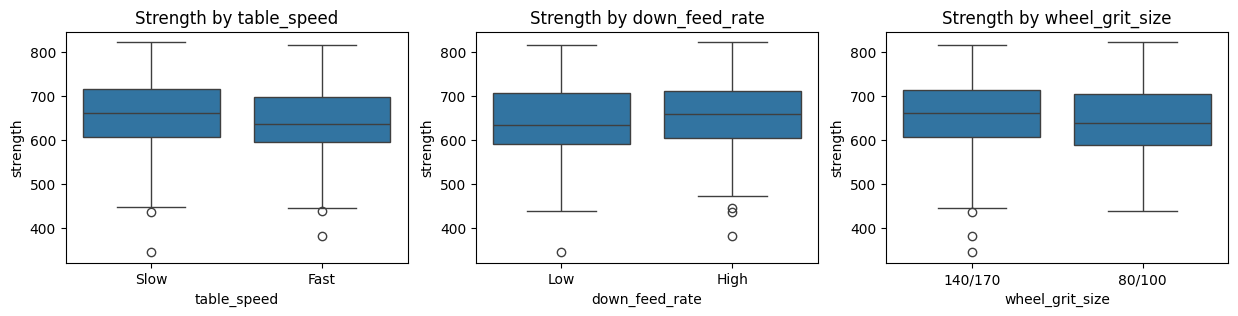

In [23]:
plt.figure(figsize=(15, 3))
for i, factor in enumerate(["table_speed", "down_feed_rate", "wheel_grit_size"]):
    plt.subplot(1, 3, i+1)
    sns.boxplot(data=df, x=factor, y="strength")
    plt.title(f"Strength by {factor}")
plt.show()

### Multi-factor ANOVA (main effects, 2-factor & 3-factor interactions)

In [24]:
from statsmodels.formula.api import ols
import statsmodels.api as sm

model = ols('''strength ~ (C(table_speed) + C(down_feed_rate) + C(wheel_grit_size)
                           + C(table_speed):C(down_feed_rate) + C(table_speed):C(wheel_grit_size)
                           + C(down_feed_rate):C(wheel_grit_size)
                           + C(table_speed):C(down_feed_rate):C(wheel_grit_size)
                           )
                           ''', data=df).fit()
anova = sm.stats.anova_lm(model, typ=2)
anova

,sum_sq,df,F,PR(>F)
C(table_speed),2.667339e+04,1.0,4.933417,0.026816
C(down_feed_rate),1.152447e+04,1.0,2.131525,0.144962
C(wheel_grit_size),1.437974e+04,1.0,2.659626,0.103592
C(table_speed):C(down_feed_rate),4.407644e+03,1.0,0.815222,0.367041
C(table_speed):C(wheel_grit_size),4.099252e+04,1.0,7.581832,0.006123
C(down_feed_rate):C(wheel_grit_size),2.029092e+02,1.0,0.037529,0.846475
C(table_speed):C(down_feed_rate):C(wheel_grit_size),1.831406e+04,1.0,3.387305,0.066328
Residual,2.551952e+06,472.0,NaN,NaN


### Visualization of **Interactions**

In [25]:
def interaction_plot(data, factor1, factor2):
    sns.pointplot(
        data=data,
        x=factor1,
        y="strength",
        hue=factor2,
        #errorbar=None,
        marker="o"
    )
    plt.title(f"{factor1} × {factor2}")

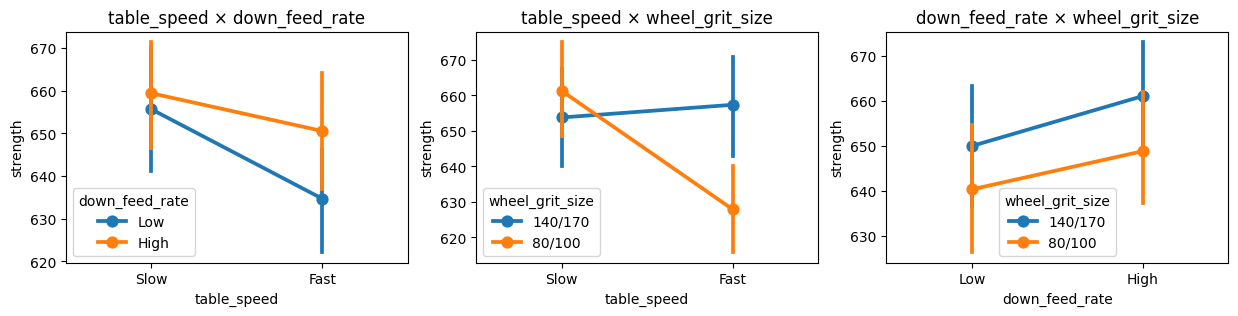

In [26]:
plt.figure(figsize=(15, 3))
plt.subplot(1, 3, 1)
interaction_plot(df, "table_speed", "down_feed_rate")
plt.subplot(1, 3, 2)
interaction_plot(df, "table_speed", "wheel_grit_size")
plt.subplot(1, 3, 3)
interaction_plot(df, "down_feed_rate", "wheel_grit_size")
plt.show()

### Tukey's Test for interactions

In [27]:
df["interaction"] = (
    df["table_speed"].astype(str) + "_" +
    df["wheel_grit_size"].astype(str)
)

df.head(5)

,id,table_speed,down_feed_rate,wheel_grit_size,strength,interaction
0,0,Slow,Low,140/170,608.781,Slow_140/170
1,1,Slow,Low,140/170,569.670,Slow_140/170
2,2,Slow,Low,140/170,689.556,Slow_140/170
3,3,Slow,Low,140/170,747.541,Slow_140/170
4,4,Slow,Low,140/170,618.134,Slow_140/170


In [28]:
tukey = pairwise_tukeyhsd(
    endog=df["strength"],
    groups=df["interaction"],
    alpha=0.05
)

print(tukey)

       Multiple Comparison of Means - Tukey HSD, FWER=0.05       
   group1       group2    meandiff p-adj   lower    upper  reject
-----------------------------------------------------------------
Fast_140/170  Fast_80/100 -29.4293 0.0113 -53.9636  -4.895   True
Fast_140/170 Slow_140/170  -3.5735 0.9819 -28.1078 20.9607  False
Fast_140/170  Slow_80/100   3.9623 0.9757  -20.572 28.4965  False
 Fast_80/100 Slow_140/170  25.8557 0.0344   1.3215   50.39   True
 Fast_80/100  Slow_80/100  33.3915 0.0028   8.8573 57.9258   True
Slow_140/170  Slow_80/100   7.5358 0.8581 -16.9985 32.0701  False
-----------------------------------------------------------------


### ANOVA and Regression
* Both have the same underlying model:

$Y = \beta_0 + \beta_AA + \beta_BB + \beta_CC + \beta_{AB}AB + \beta_{AC}AC + \beta_{AC}AC + \beta_{ABC}ABC + \epsilon$

where $A =$ table speed, $B =$ down-feed rate, $C =$ grit size.

In [29]:
print(model.params)

Intercept                                                                       659.740917
C(table_speed)[T.Slow]                                                            2.719733
C(down_feed_rate)[T.Low]                                                         -4.806933
C(wheel_grit_size)[T.80/100]                                                    -18.375800
C(table_speed)[T.Slow]:C(down_feed_rate)[T.Low]                                 -12.586550
C(table_speed)[T.Slow]:C(wheel_grit_size)[T.80/100]                              12.257417
C(down_feed_rate)[T.Low]:C(wheel_grit_size)[T.80/100]                           -22.106967
C(table_speed)[T.Slow]:C(down_feed_rate)[T.Low]:C(wheel_grit_size)[T.80/100]     49.415333
dtype: float64


### Larger coefficients doesn't mean larger effect, significance matters.

###Model Diagnostics
* **Normality of errors**: The residuals are approximately normally distributed.
* **Homogeneity of variance**: The residuals have approximately the same variance across groups/treatment combinations.

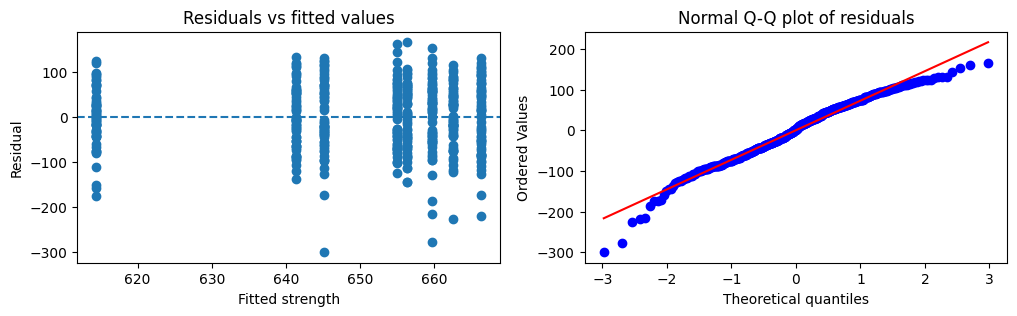

In [30]:

import scipy.stats as stats
residuals = model.resid
fitted = model.fittedvalues

plt.figure(figsize=(12, 3))
plt.subplot(1, 2, 1)
plt.scatter(fitted, residuals)
plt.axhline(0, linestyle="--")
plt.xlabel("Fitted strength")
plt.ylabel("Residual")
plt.title("Residuals vs fitted values")

plt.subplot(1, 2, 2)
stats.probplot(residuals, dist="norm", plot=plt)
plt.title("Normal Q-Q plot of residuals")
plt.show()

## Summary


* DoE is a systematic way to plan experiments to understand and improve a process.
* OFAT is inefficient because it cannot effectively identify interactions between factors.
* ANOVA helps determine whether observed differences in responses are statistically significant.
* One-way ANOVA examines the effect of a single factor.
* Factorial designs study multiple factors simultaneously and allow us to detect interactions.
* Interaction effects occur when the effect of one factor depends on the level of another factor.
* Regression and ANOVA are closely connected—a factorial ANOVA can be represented as a regression model.